In [40]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('consulta.csv', sep=';', encoding='latin-1')

In [42]:
df.head()

,Localidade,Variável,2012
0,Goiânia,Vítimas em Acidentes de Trânsito - Morte no Lo...,125
1,Goiânia,Vítimas em Acidentes de Trânsito - Morte Poste...,185
2,Jataí,Vítimas em Acidentes de Trânsito - Morte no Lo...,20
3,Jataí,Vítimas em Acidentes de Trânsito - Morte Poste...,6


In [43]:
print(df['Localidade'].unique())

['Goiânia' 'Jataí']


In [44]:
df['2012'] = pd.to_numeric(df['2012'], errors='coerce')

In [ ]:
# KPI 1: Total por Localidade
kpi_total = df.groupby('Localidade')['2012'].sum()

# KPI 2: % de Participação
total_geral = df['2012'].sum()
kpi_participacao = (kpi_total / total_geral) * 100

print("--- RELATÓRIO DE BI ---")
print(f"Cidades Analisadas: {df['Localidade'].unique()}")
print(f"\nParticipação em vitimas de acidente de trânsito por cidade (%):")
for localidade, participacao in kpi_participacao.items():
    print(f"  {localidade}: {participacao:.2f}%")

--- RELATÓRIO DE BI ---
Cidades Analisadas: ['Goiânia' 'Jataí']

Participação por Cidade (%):
  Goiânia: 92.26%
  Jataí: 7.74%


In [1]:
import pandas as pd

# 1. FORÇAR O PANDAS A MOSTRAR TODAS AS LINHAS E COLUNAS
pd.set_option('display.max_rows', None)  # Sem limite de linhas
pd.set_option('display.max_columns', None)  # Sem limite de colunas
pd.set_option('display.width', None)  # Ajusta a largura da tela

# 2. LER O ARQUIVO (Ajustado para o seu print: sep=';' e encoding='latin-1')
# Se o arquivo estiver na pasta 'atividade_salarios', coloque o caminho certo:
df = pd.read_csv('consulta.csv', sep=';', encoding='latin-1')

# 3. LIMPEZA RELÂMPAGO (Tirando as aspas que apareceram na sua imagem)
df.columns = df.columns.str.replace('"', '')
df = df.apply(lambda x: x.str.replace('"', '') if x.dtype == "object" else x)

# 4. MOSTRAR A TABELA COMPLETA
print("--- EXIBINDO TABELA COMPLETA ---")
display(df) 

# --- AGORA OS KPIs DE BI (Requisito da sua atividade) ---

# Converter a coluna de valores (2012) para número para poder calcular
df['2012'] = pd.to_numeric(df['2012'], errors='coerce')

# KPI 1: Soma de Vítimas por Localidade
kpi_total = df.groupby('Localidade')['2012'].sum()

# KPI 2: Média de Vítimas por Categoria
kpi_media = df.groupby('Localidade')['2012'].mean()

# KPI 3: Percentual de Participação no Total de Goiás
total_geral = df['2012'].sum()
kpi_percentual = (kpi_total / total_geral) * 100

print("\n--- RESULTADOS DOS KPIs (BI) ---")
resumo = pd.DataFrame({
    'Total Vítimas': kpi_total,
    'Média p/ Categoria': kpi_media,
    '% do Total Estado': kpi_percentual
})
display(resumo)

--- EXIBINDO TABELA COMPLETA ---


,Localidade,Variável,2012
0,Goiânia,Vítimas em Acidentes de Trânsito - Morte no Lo...,125
1,Goiânia,Vítimas em Acidentes de Trânsito - Morte Poste...,185
2,Jataí,Vítimas em Acidentes de Trânsito - Morte no Lo...,20
3,Jataí,Vítimas em Acidentes de Trânsito - Morte Poste...,6



--- RESULTADOS DOS KPIs (BI) ---


,Total Vítimas,Média p/ Categoria,% do Total Estado
Localidade,,,
Goiânia,310,155.0,92.261905
Jataí,26,13.0,7.738095


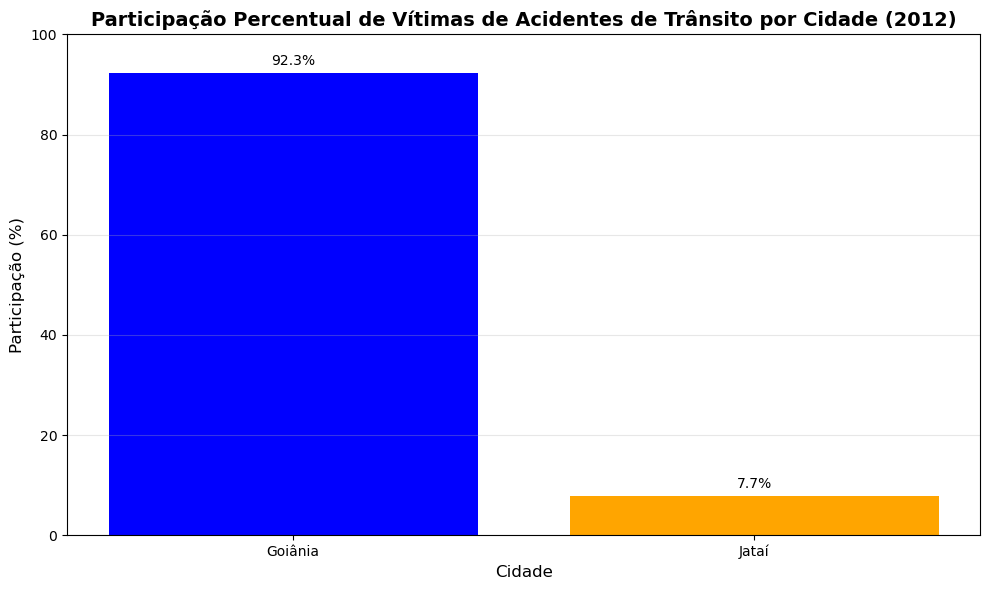

Gráfico salvo como 'analise_acidentes_goias.png'


In [3]:
import matplotlib.pyplot as plt

# Gráfico de Barras para Participação Percentual
plt.figure(figsize=(10, 6))
bars = plt.bar(kpi_percentual.index, kpi_percentual.values, color=['blue', 'orange'])
plt.title('Participação Percentual de Vítimas de Acidentes de Trânsito por Cidade (2012)', fontsize=14, fontweight='bold')
plt.xlabel('Cidade', fontsize=12)
plt.ylabel('Participação (%)', fontsize=12)
plt.ylim(0, 100)

# Adicionar valores nas barras
for bar, value in zip(bars, kpi_percentual.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{value:.1f}%', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('analise_acidentes_goias.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico salvo como 'analise_acidentes_goias.png'")